# LDV Cable Coupling — Frequency-Domain Analysis

Companion to [LDV_Cable_Coupling_v2.ipynb](LDV_Cable_Coupling_v2.ipynb)
(the time-domain, per-frequency notebook). Shares the in-memory dataset cache in
[`ldv_analysis/io.py`](ldv_analysis/io.py), so loads are free if the v2 notebook
already ran in this kernel.

This notebook estimates the **ground-to-cable strain-transfer frequency response**
with Welch transfer functions and reproduces the four-panel **Fig. 3** of
[`Papers/Cable_coupling_v1_Simone.pdf`](Papers/Cable_coupling_v1_Simone.pdf).
All reusable logic lives in [`ldv_analysis/freqdomain.py`](ldv_analysis/freqdomain.py)
and [`ldv_analysis/plotting.py`](ldv_analysis/plotting.py).

### Signals (per dataset, full sweep record, displacement [m])

| Signal | Definition | Role |
|---|---|---|
| $X(t)=\delta L(t)$ | endpoint-pair span change $u_\parallel(\text{right})-u_\parallel(\text{left})$ (default; or shaker) | **input** (ground motion) |
| $Y_1(t)=\delta x_\ell(t)$ | $\sum$ per-segment 3-D arc-length elongation | axial **output** (strain) |
| $Y_2(t)=u_{\perp,\mathrm{mid}}(t)$ | midpoint displacement $\perp$ chord, signed along the static-sag direction | bending **output** |

### Transfer functions (H1 estimator, output relative to input)
$$H(f)=\frac{S_{YX}(f)}{S_{XX}(f)}=\frac{\texttt{csd}(X,Y)}{\texttt{welch}(X)},\qquad
\gamma^2(f)=\texttt{coherence}(X,Y)$$

| § | Content |
|---|---|
| 0 | Imports, plot style, dataset selection, loading, geometry |
| 1 | Build the three signals $X$, $Y_1$, $Y_2$ |
| 2 | Welch transfer functions $H_\eta$, $H_\mathrm{mid}$ and coherence $\gamma^2$ |
| 3 | Four-panel Fig. 3 reproduction |
| 4 | STFT-per-frequency cross-check (overlaid on the Welch curves) |
| 5 | Resonance characterisation ($f_1$, $Q$, $\zeta$) |
| 6 | Theory overlay: quasi-static $\eta=1/(1+\Theta)$ and the amplification region |


---
## § 0  Imports, Plot Style, Data & Geometry

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Editable reload while iterating on the package
%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, analysis, freqdomain, plotting

plt.rcParams.update({
    "font.size": 12, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 130, "savefig.dpi": 300, "figure.autolayout": False,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.4, "image.cmap": "RdBu_r",
})
# Cable colours are the maintained package palette (config.CABLE_COLORS, applied
# via config.dataset_style). The old notebook-local `PALETTE` dict was the same
# idea; plot_fig3_transfer uses dataset_style so colours stay consistent.
print(f"{len(la.ALL_DATASETS)} datasets in catalogue.")

46 datasets in catalogue.


**Dataset selection.** Edit `ACTIVE_LABELS`. Overlaying 2–4 datasets that
span a range of $\Theta$ (e.g. different cables or gap sizes) makes the theory
comparison in §6 most informative. Many overlaid curves make the four-panel plot
busy.

In [3]:
# Examples — uncomment a set, or build your own.
ACTIVE_LABELS = [f"Cable{i}_10cm" for i in range(6, 7)]          # all cables, 10 cm
# ACTIVE_LABELS = ["Cable5_5cm", "Cable5_10cm", "Cable5_15cm"]      # gap sweep
# ACTIVE_LABELS = ["Cable5_10cm", "Cable5_10cm_Sag"]               # taut vs sag

# Default: three cables of differing stiffness/weight -> differing Theta.
#ACTIVE_LABELS = ["Cable1_5cm_Sag","Cable7_10cm_Sag","Cable4_10cm", "Cable5_10cm_Sag", "Cable6_15cm_Sag", "Cable3_15cm"] #, "Cable7_15cm_Sag"]

#ACTIVE_LABELS = ["Cable3_5cm","Cable3_5cm_Sag","Cable3_10cm_Sag","Cable3_10cm", "Cable3_15cm_Sag", "Cable3_15cm"] #, "Cable7_15cm_Sag"]

#ACTIVE_LABELS = ["Cable4_5cm","Cable4_5cm_Sag","Cable4_10cm_Sag","Cable4_10cm", "Cable4_15cm_Sag", "Cable4_15cm"] #, "Cable7_15cm_Sag"]
#ACTIVE_LABELS = ["Cable6_5cm","Cable6_5cm_Sag","Cable6_10cm_Sag","Cable6_10cm", "Cable6_15cm_Sag", "Cable6_15cm"] #, "Cable7_15cm_Sag"]
#ACTIVE_LABELS = ["Cable7_5cm","Cable7_5cm_Sag","Cable7_10cm_Sag","Cable7_10cm", "Cable7_15cm_Sag", "Cable7_15cm"] #, "Cable7_15cm_Sag"]


DATASETS = config.select_datasets(ACTIVE_LABELS)
print("Active:", [ds['label'] for ds in DATASETS])

Active: ['Cable6_10cm']


In [4]:
# Load cable + shaker .mat files (cached in-memory after first call).
for cfg in DATASETS:
    io.load_cable_dataset(cfg, verbose=False)
    print(f"  {cfg['label']:18s}  n_sensors={cfg['n_sensors']:2d}  "
          f"fs={cfg['fs']:.0f} Hz  duration={cfg['t'][-1]:.2f} s  "
          f"gap={cfg['gap_m']*100:.0f} cm")

  Cable6_10cm         n_sensors=17  fs=5000 Hz  duration=12.00 s  gap=10 cm


**Geometry.** `analysis.prepare_geometry` computes the chord direction,
static sag, $\Theta$ and the quasi-static $\eta_\mathrm{pred}=1/(1+\Theta)$ used
later. (For the side/top-view plots run `plotting.plot_initial_geometry(DATASETS)`
instead — it sets the same fields.)

In [5]:
for cfg in DATASETS:
    analysis.prepare_geometry(cfg, sag_use_3d=True, sag_use_parabola=True)
    print(f"  {cfg['label']:18s}  L_chord={cfg['chord_len']*1e3:6.1f} mm  "
          f"sag={cfg['static_sag']*1e3:5.3f} mm  "
          f"Theta={cfg['theta_pred']:.4g}  eta_pred={cfg['eta_pred']:.3f}")

  Cable6_10cm         L_chord=  91.5 mm  sag=0.399 mm  Theta=0.03544  eta_pred=0.966


---
## § 1  Build the Three Signals

`freqdomain.build_coupling_signals` integrates the full-record shaker and cable
velocities to displacement (no bandpass — we want the broadband response for
Welch averaging) and forms $X=\delta L$, $Y_1=\delta x_\ell$, and
$Y_2=u_{\perp,\mathrm{mid}}$.

**Reference $\delta L$ (`x_source`).** $\delta L$ is a *span change* between the
segment's two contact points, not a single point's motion. We default to
`x_source='ends'`: the cable-native span change measured from the two endpoint
sensors,
$$\delta L(t)=u_\parallel(\text{idx\_right},t)-u_\parallel(\text{idx\_left},t),$$
both projected on the chord. This shares its endpoints with $\delta x_\ell$, so
$\eta$ cleanly isolates bending stress relief, and it avoids the shaker's
cross-instrument calibration and sign-flip. Set `x_source='shaker'` to use the
imposed ground motion instead (the projected shaker displacement), or
`'left_sensor'` to inspect a single-endpoint reference (not a true $\delta L$).

The midpoint sensor is the one nearest the chord mid-span; the sag direction
$\hat e_\mathrm{sag}$ is its static perpendicular offset from the chord (falling
back to gravity $-\hat z$ for a taut cable), so $Y_2$ is signed.

In [6]:
# δL reference: 'ends' (endpoint-pair span change, recommended),
# 'shaker' (projected shaker displacement), or 'left_sensor' (single endpoint).
X_SOURCE = 'ends'

for cfg in DATASETS:
    sig = freqdomain.build_coupling_signals(cfg, x_source=X_SOURCE)
    fb = " (gravity fallback)" if sig['sag_dir_fallback'] else ""
    print(f"  {cfg['label']:18s}  idx_mid={sig['idx_mid']:2d}  "
          f"e_sag={np.round(sig['e_sag'], 2)}{fb}")
    print(f"      X={X_SOURCE!r:13s}  rms  X(δL)={sig['X'].std()*1e6:7.2f}  "
          f"Y1(δxₗ)={sig['Y_eta'].std()*1e6:7.2f}  "
          f"Y2(u⊥mid)={sig['Y_mid'].std()*1e6:7.2f}  [µm]")

  Cable6_10cm         idx_mid= 8  e_sag=[-0.   -0.21  0.98]
      X='ends'         rms  X(δL)=  29.55  Y1(δxₗ)=  33.38  Y2(u⊥mid)=  84.75  [µm]


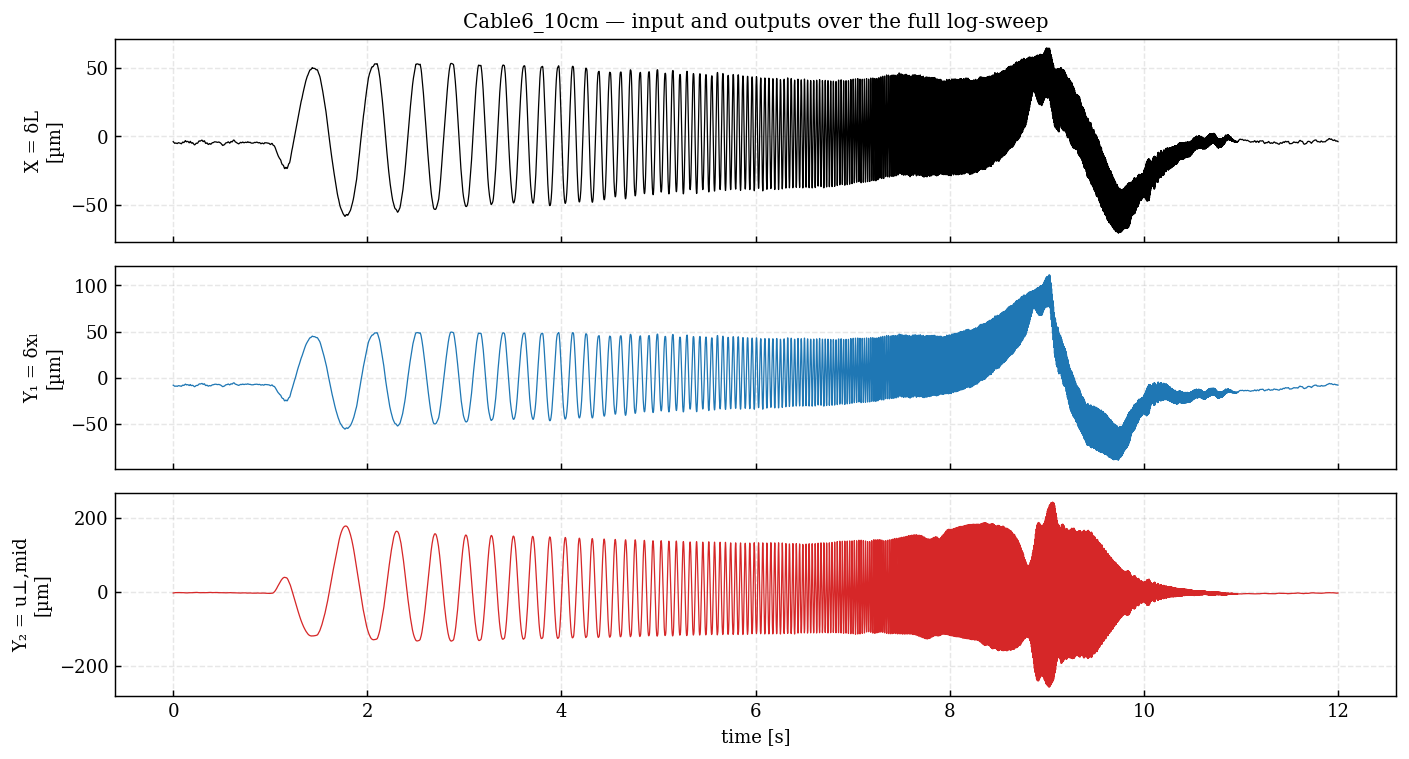

In [7]:
# Quick look at the three time series for the first dataset (full sweep).
cfg0 = DATASETS[0]
s0 = cfg0['fd_signals']
t = s0['t']
fig, ax = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
ax[0].plot(t, s0['X'] * 1e6, color='k', lw=0.7);     ax[0].set_ylabel('X = δL\n[µm]')
ax[1].plot(t, s0['Y_eta'] * 1e6, color='C0', lw=0.7); ax[1].set_ylabel('Y₁ = δxₗ\n[µm]')
ax[2].plot(t, s0['Y_mid'] * 1e6, color='C3', lw=0.7); ax[2].set_ylabel('Y₂ = u⊥,mid\n[µm]')
ax[2].set_xlabel('time [s]')
ax[0].set_title(f"{cfg0['label']} — input and outputs over the full log-sweep")
fig.tight_layout(); plt.show()

---
## § 2  Welch Transfer Functions & Coherence

`freqdomain.compute_transfer_functions` uses
`nperseg = round(2·fs)`, `noverlap = nperseg//2`, Hann window, and forms
$H_\eta=S_{Y_1 X}/S_{XX}$ and $H_\mathrm{mid}=S_{Y_2 X}/S_{XX}$ with the matching
coherences. We also run `resonance_summary` here (it derives $f_1$ from
$|H_\mathrm{mid}|$, which §3 needs for the resonance markers).

In [8]:
# Search for f1 up to this frequency; widen if the peak is higher.
RES_FMAX = 300.0

for cfg in DATASETS:
    tf = freqdomain.compute_transfer_functions(cfg)
    freqdomain.resonance_summary(cfg, tf, f_max=RES_FMAX)
    f = tf['f']
    for fmax in (60.0, RES_FMAX):
        band = (f > 0) & (f <= fmax)
        frac = (tf['coh_eta'][band] >= 0.7).mean()
        print(f"  {cfg['label']:18s}  ≤{fmax:5.0f} Hz: "
              f"γ²(η)≥0.7 in {frac*100:4.0f}% of bins", end='')
        print(f"   |   df={tf['df']:.2f} Hz, nperseg={tf['nperseg']}" if fmax == 60 else "")

  Cable6_10cm         ≤   60 Hz: γ²(η)≥0.7 in  100% of bins   |   df=0.50 Hz, nperseg=10000
  Cable6_10cm         ≤  300 Hz: γ²(η)≥0.7 in  100% of bins


---
## § 3  Four-Panel Fig. 3 Reproduction

`plotting.plot_fig3_transfer` overlays all selected datasets:

- **(a)** $|H_\mathrm{mid}(f)|$ normalised to its own max — *normalized midpoint amplitude*
- **(b)** $\arg H_\mathrm{mid}(f)$ [deg], unwrapped — *midpoint phase*
- **(c)** $|H_\eta(f)|\times 100\,\%$ — *strain transfer amplitude*
- **(d)** $\arg H_\eta(f)$ [deg], unwrapped — *strain transfer phase*

Bins with $\gamma^2<0.7$ are greyed out; high-coherence bins are drawn in the
cable colour. Vertical dotted lines mark $f_1$; panel (c) shows the quasi-static
$\eta=1/(1+\Theta)$ as a dashed line per dataset (see §6).

> **Note** — the Simone Fig. 3 uses compliant cables whose resonance sits below
> 60 Hz. For these stiff, short, taut segments the $|H_\mathrm{mid}|$ peak is
> typically **above 60 Hz**, so widen `F_MAX_PLOT` (e.g. 200 Hz) to bring the
> resonance into view.

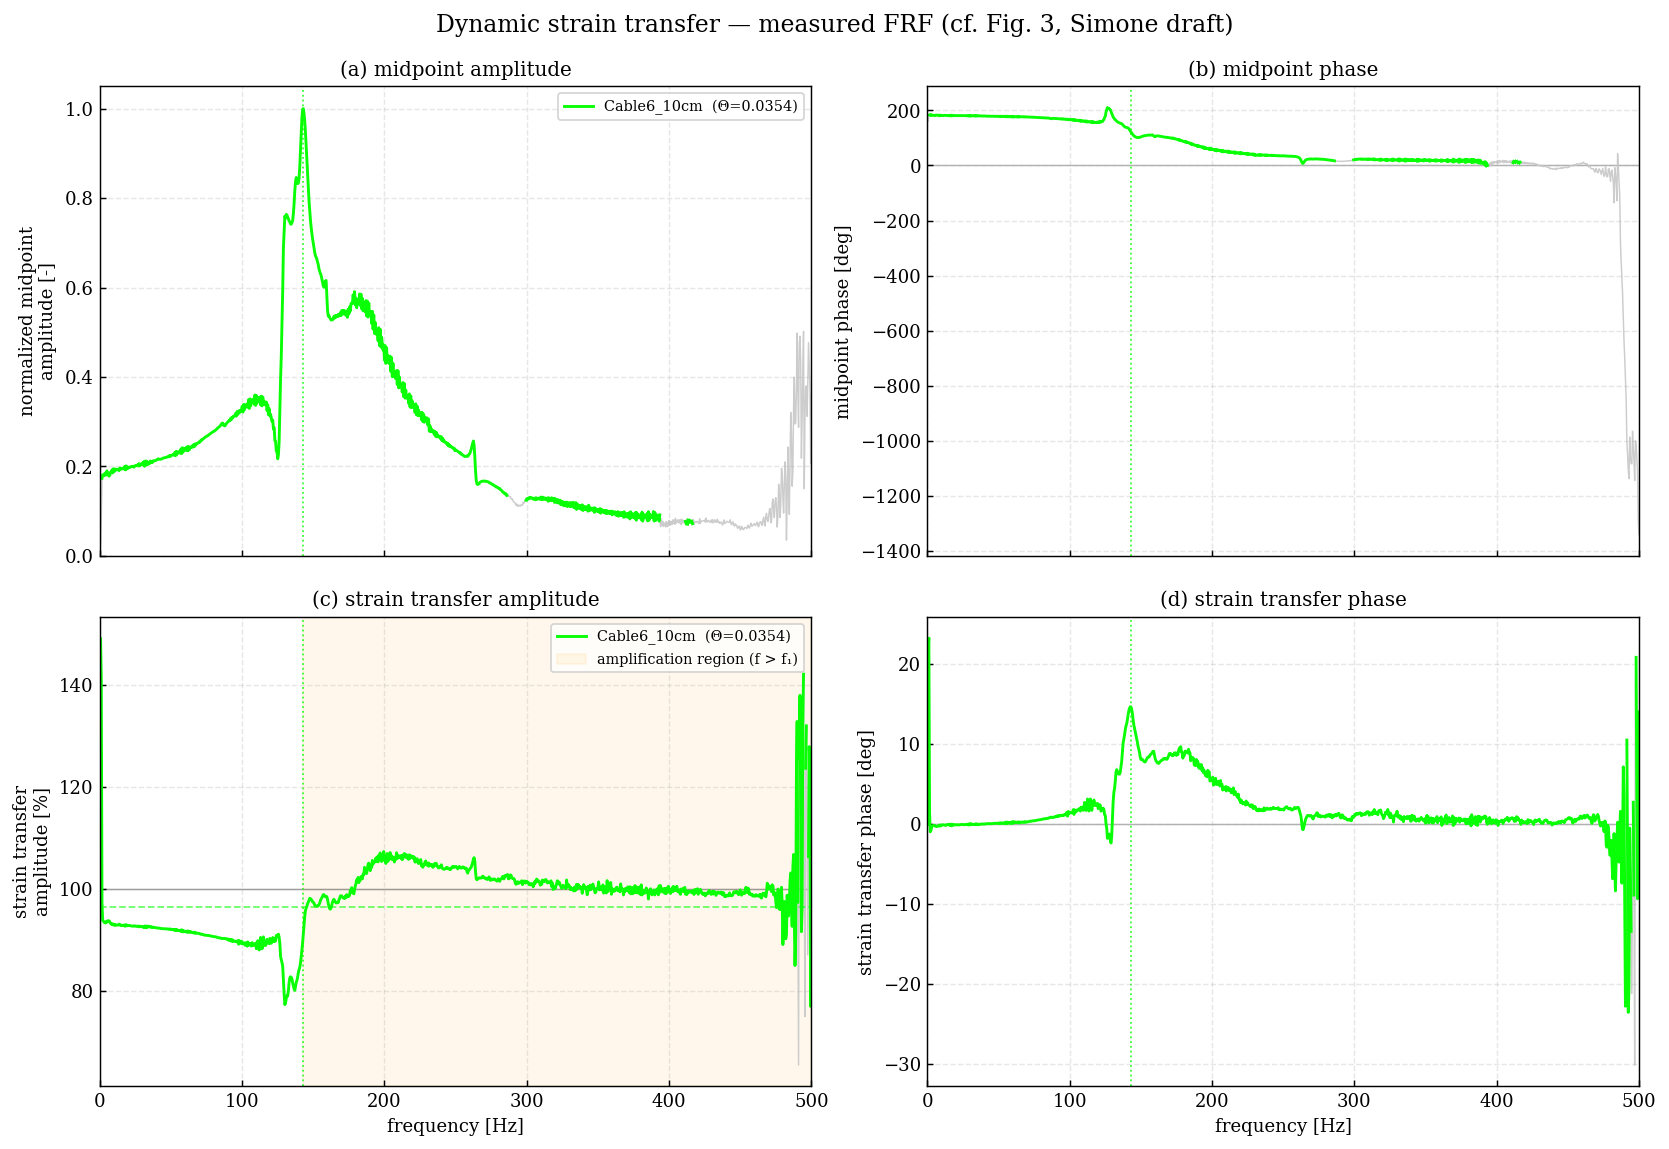

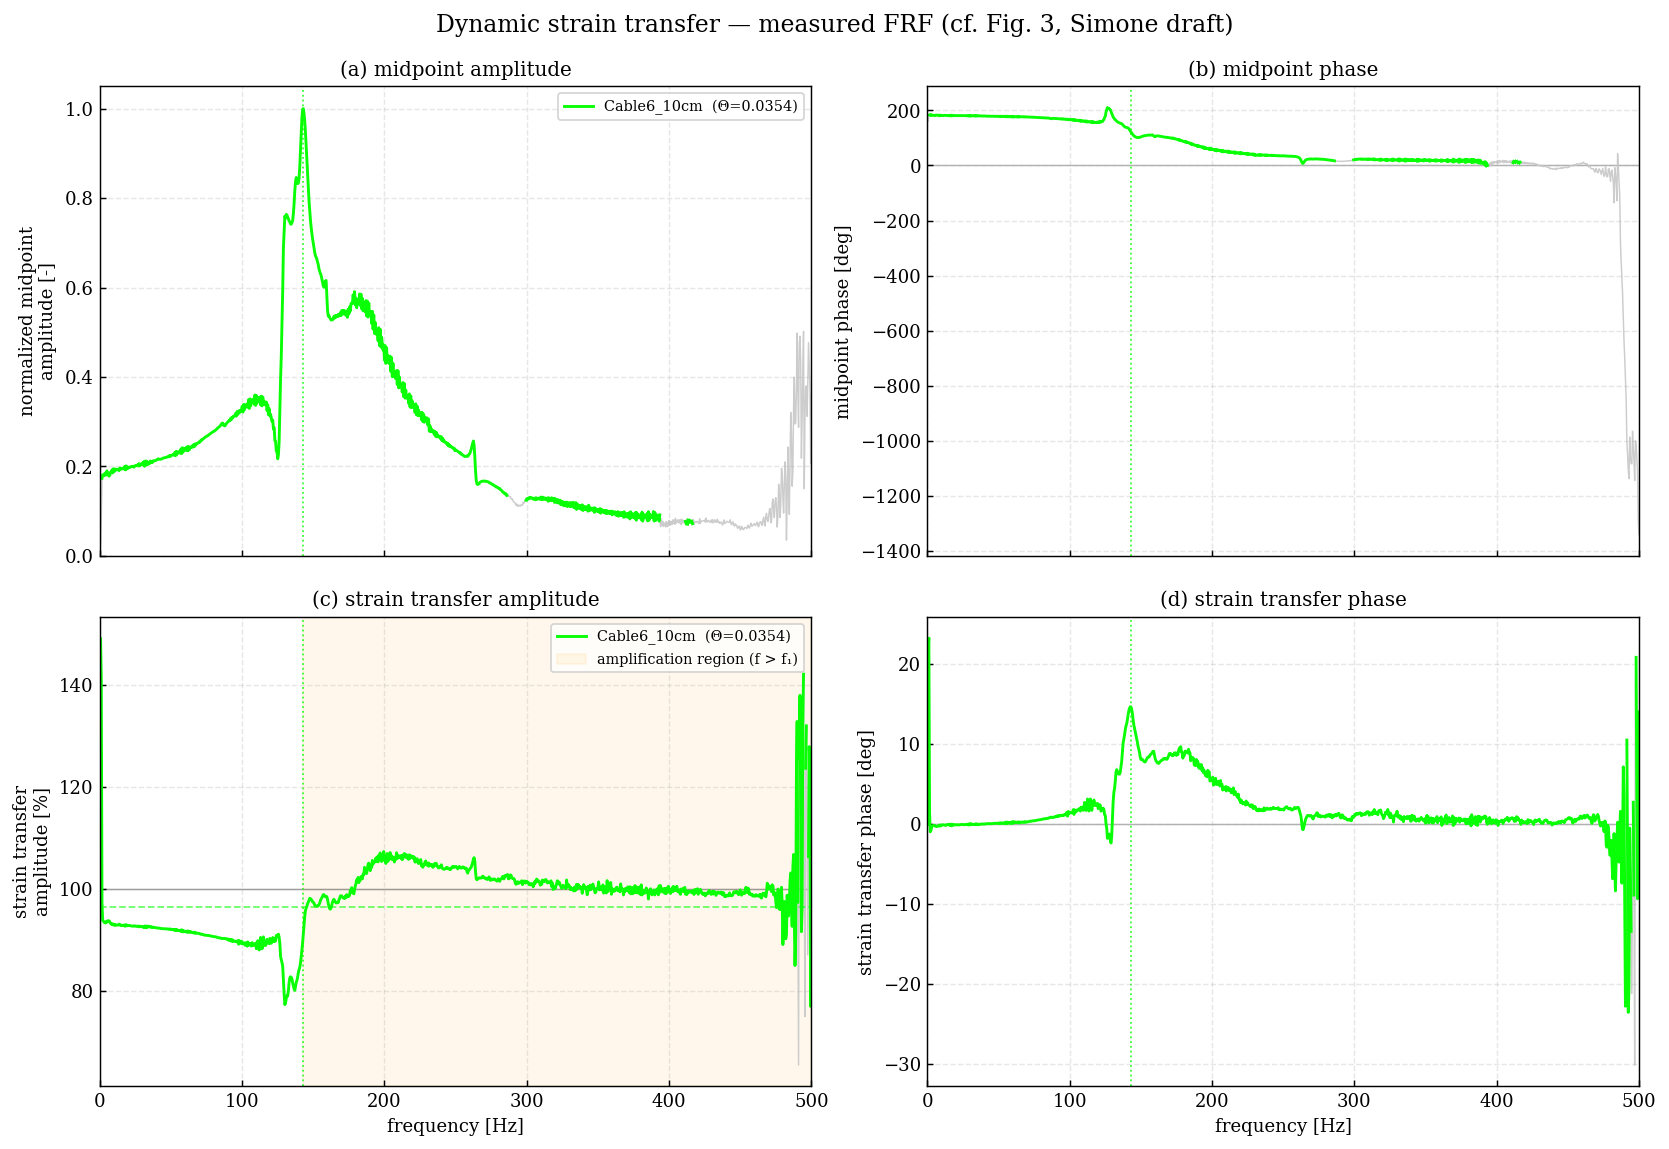

In [9]:
F_MAX_PLOT = 500.0   # paper style; widen (e.g. 200) to capture the resonance

plotting.plot_fig3_transfer(DATASETS, f_max=F_MAX_PLOT, coh_thresh=0.7,
                            show_stft=False, show_eta_pred=True)

---
## § 4  STFT-per-Frequency Cross-Check

For each target frequency we extract a window of $\pm N$ cycles centred on the
sweep arrival time $t_c(f)$ (`config.sweep_time_of_frequency`), taper, FFT $X$,
$Y_1$, $Y_2$, and read the bin closest to $f_\mathrm{target}$ to form a complex
point estimate $H(f_\mathrm{target})$. Agreement with the Welch curves validates
the pipeline.

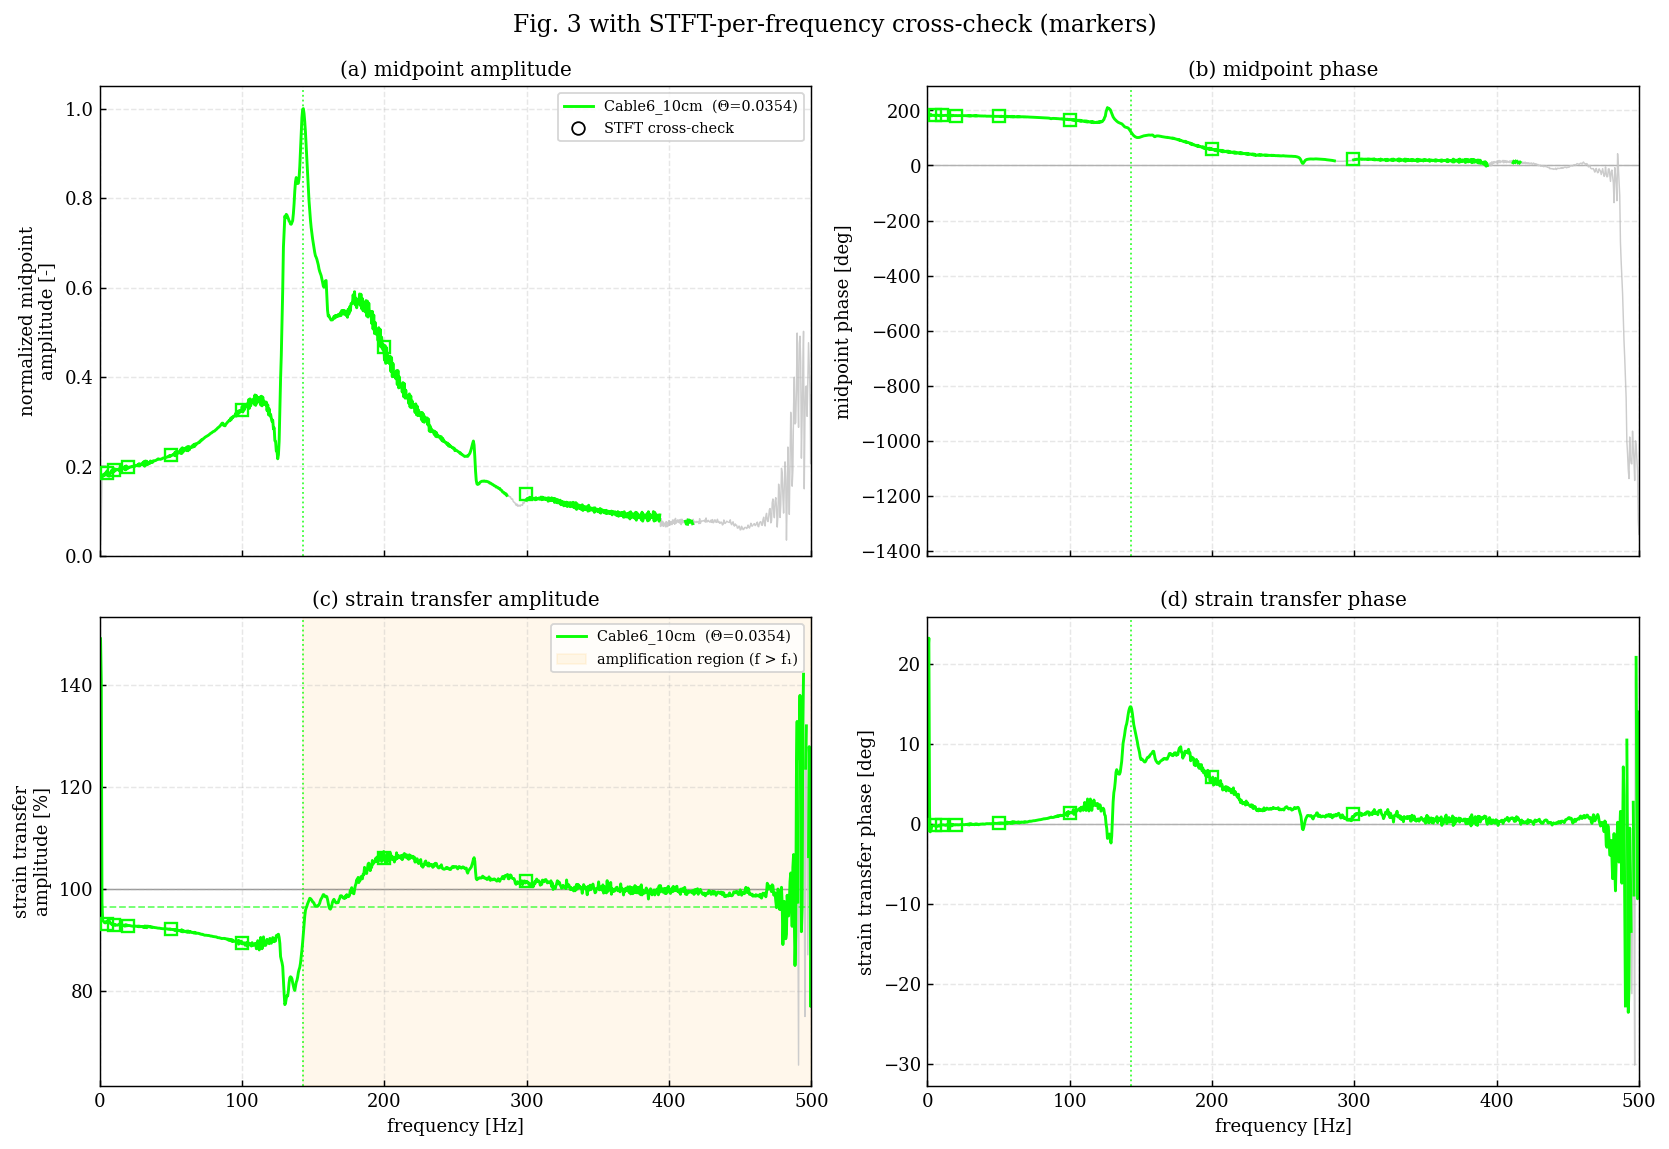

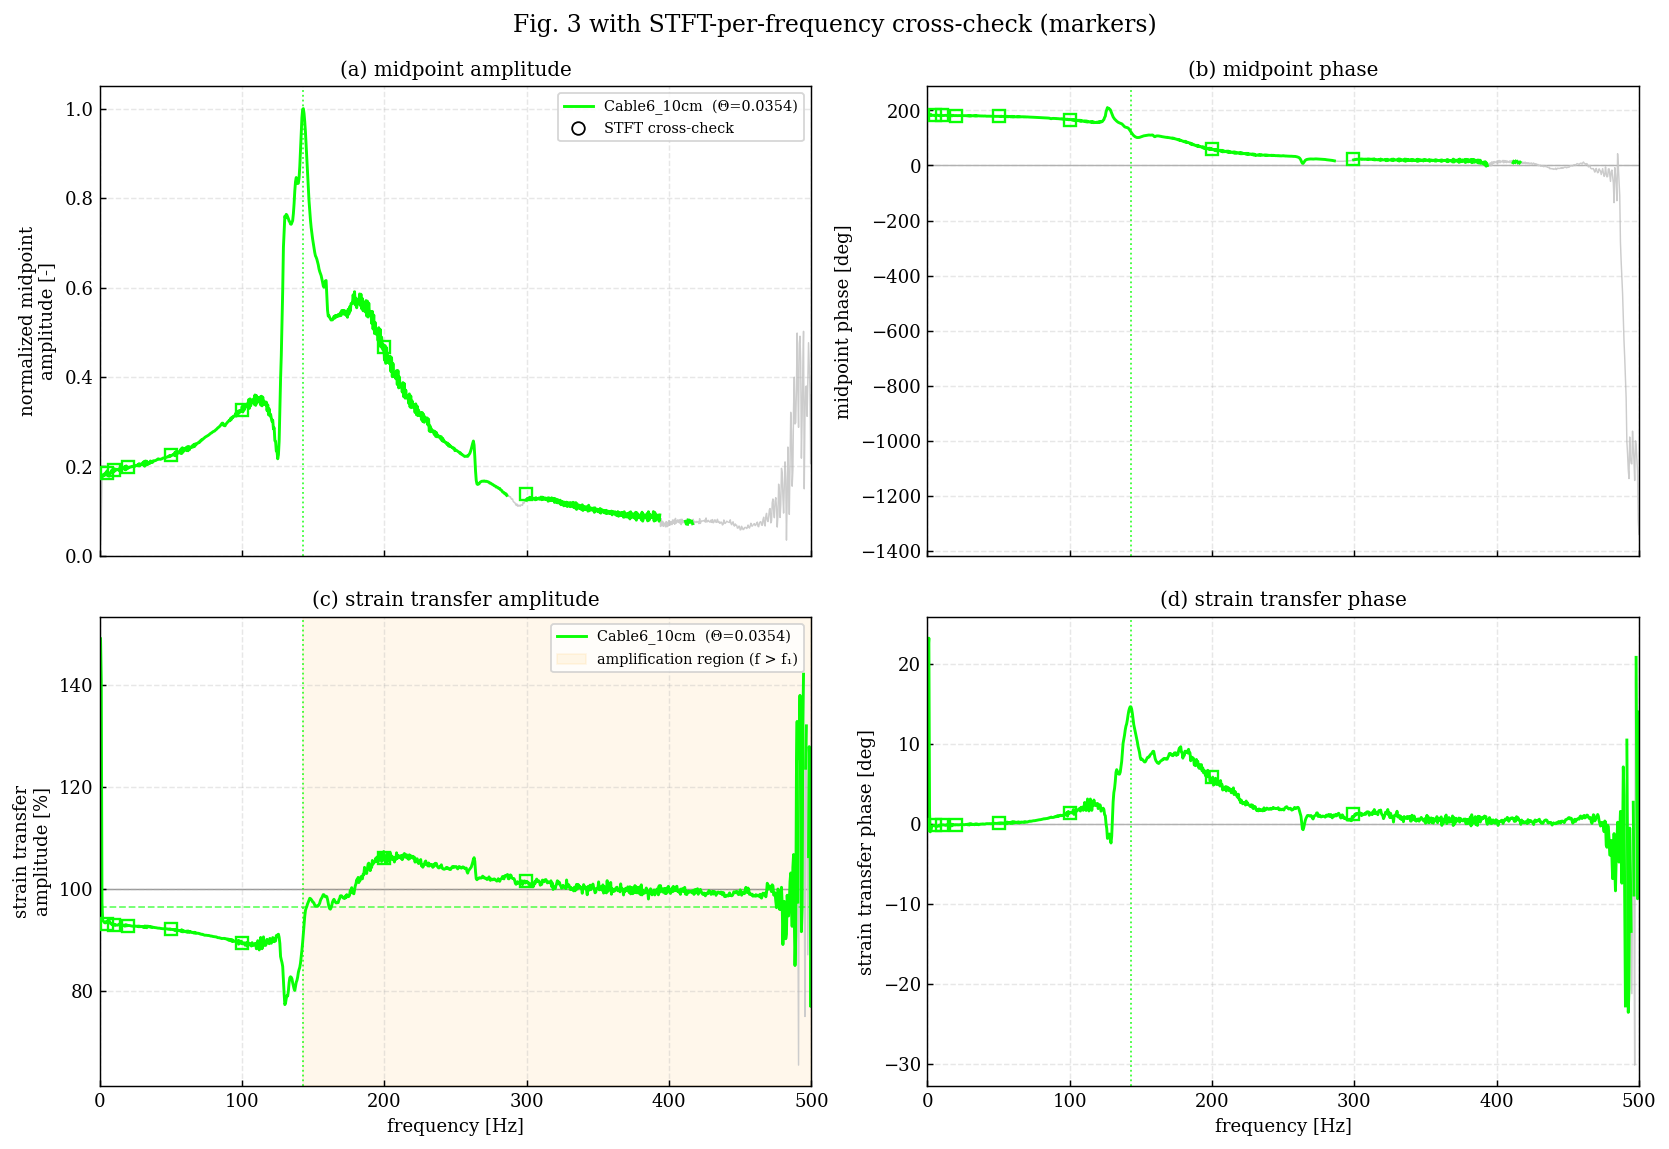

In [10]:
STFT_FREQS = [5, 10, 20, 50, 100, 200, 300]

for cfg in DATASETS:
    freqdomain.stft_point_transfers(cfg, STFT_FREQS)

# Overlay the point estimates (open markers) on the Welch curves.
plotting.plot_fig3_transfer(DATASETS, f_max=max(F_MAX_PLOT, max(STFT_FREQS)),
                            coh_thresh=0.7, show_stft=True, show_eta_pred=True,
                            title='Fig. 3 with STFT-per-frequency cross-check (markers)')

In [11]:
# Numerical agreement: STFT point vs Welch curve interpolated at the same f.
rows = []
for cfg in DATASETS:
    tf, st = cfg['fd_tf'], cfg['fd_stft']
    for i, fq in enumerate(st['f']):
        rows.append(dict(
            dataset=cfg['label'], f_Hz=round(fq, 1),
            eta_STFT_pct=round(abs(st['H_eta'][i]) * 100, 1),
            eta_Welch_pct=round(float(np.interp(fq, tf['f'], np.abs(tf['H_eta']))) * 100, 1),
            mid_STFT=round(abs(st['H_mid'][i]) * 1e3, 3),
            mid_Welch=round(float(np.interp(fq, tf['f'], np.abs(tf['H_mid']))) * 1e3, 3),
        ))
pd.DataFrame(rows)

,dataset,f_Hz,eta_STFT_pct,eta_Welch_pct,mid_STFT,mid_Welch
0,Cable6_10cm,5.0,93.1,93.5,2745.717,2806.358
1,Cable6_10cm,10.0,93.0,93.1,2823.717,2776.090
2,Cable6_10cm,20.0,92.8,92.9,2922.594,2896.205
3,Cable6_10cm,50.0,92.1,92.1,3315.402,3315.366
4,Cable6_10cm,100.0,89.4,89.3,4821.127,4932.968
5,Cable6_10cm,200.0,106.1,105.6,6908.168,6459.230
6,Cable6_10cm,299.4,101.5,101.4,2047.543,1835.790


---
## § 5  Resonance Characterisation

$f_1$ is the global max of $|H_\mathrm{mid}(f)|$ below `RES_FMAX`. A driven
single-DOF resonance is fitted around it to extract the quality factor $Q$ and
damping ratio $\zeta=1/(2Q)$. The theoretical clamped–clamped beam fundamental
$f_1^\mathrm{th}=\tfrac{22.4}{2\pi L^2}\sqrt{EI/\rho A}$ (Simone Eq. 18, with
$L=L_\mathrm{chord}$) is shown for comparison.

> For these short stiff segments $f_1^\mathrm{th}$ is often in the kHz range,
> far above the measured peak — the observed sub-300 Hz resonance reflects the
> coupled rig/added-mass system rather than the bare clamped-segment mode, which
> is why the paper stresses that resonance must be characterised empirically.

In [12]:
rows = []
for cfg in DATASETS:
    r = cfg['fd_resonance']
    rows.append(dict(
        dataset=r['label'],
        Theta=round(r['theta_pred'], 4) if r['theta_pred'] is not None else None,
        eta_pred=round(r['eta_pred'], 3) if r['eta_pred'] is not None else None,
        f1_meas_Hz=round(r['f1_meas'], 1),
        f1_fit_Hz=round(r['f1_fit'], 1) if np.isfinite(r['f1_fit']) else None,
        Q=round(r['Q'], 2) if np.isfinite(r['Q']) else None,
        zeta=round(r['zeta'], 4) if np.isfinite(r['zeta']) else None,
        f1_theory_Hz=round(r['f1_theory'], 1) if r['f1_theory'] else None,
    ))
res_table = pd.DataFrame(rows)
res_table

,dataset,Theta,eta_pred,f1_meas_Hz,f1_fit_Hz,Q,zeta,f1_theory_Hz
0,Cable6_10cm,0.0354,0.966,143.0,150.9,4.02,0.1245,562.7


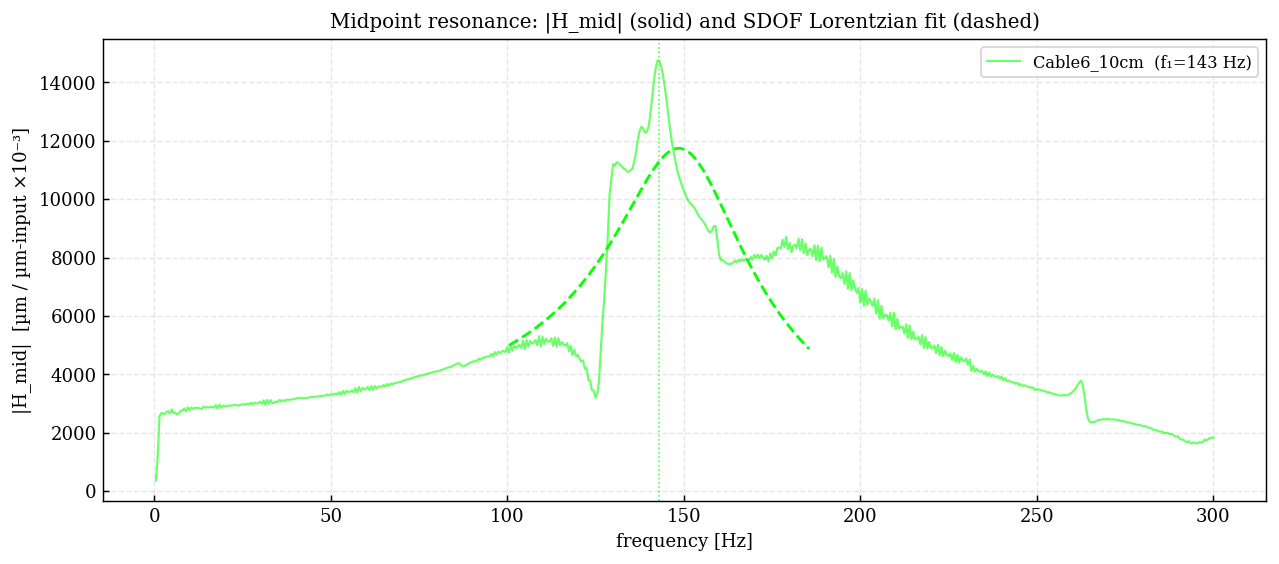

In [13]:
# Lorentzian fit overlay on |H_mid| for each dataset.
fig, ax = plt.subplots(figsize=(10, 4.5))
for cfg in DATASETS:
    col, _, _ = config.dataset_style(cfg)
    tf, r = cfg['fd_tf'], cfg['fd_resonance']
    band = (tf['f'] > 0) & (tf['f'] <= RES_FMAX)
    ax.plot(tf['f'][band], np.abs(tf['H_mid'][band]) * 1e3, color=col, lw=1.2,
            alpha=0.6, label=f"{cfg['label']}  (f₁={r['f1_meas']:.0f} Hz)")
    fit = r['fit']
    if fit['success']:
        ax.plot(fit['fit_f'], np.asarray(fit['fit_mag']) * 1e3, color=col,
                ls='--', lw=1.6)
    ax.axvline(r['f1_meas'], color=col, ls=':', lw=0.9, alpha=0.7)
ax.set_xlabel('frequency [Hz]'); ax.set_ylabel('|H_mid|  [µm / µm-input ×10⁻³]')
ax.set_title('Midpoint resonance: |H_mid| (solid) and SDOF Lorentzian fit (dashed)')
ax.legend(fontsize=9); fig.tight_layout(); plt.show()

---
## § 6  Theory Overlay

The quasi-static limit predicts a flat strain transfer $\eta=1/(1+\Theta)$ below
resonance, where $\Theta=\tfrac12(w_0/r)^2$ from the measured sag (panel (c)
dashed lines). Above $f_1$ the model predicts constructive bending coupling that
amplifies the transfer well over 100 % (the shaded *amplification region*), with
the spike severity growing with $\Theta$.

Below we compare the **measured** low-frequency strain transfer (mean
$|H_\eta|$ over a quasi-static band, high-coherence bins only) against the
predicted $\eta=1/(1+\Theta)$.

In [14]:
QS_BAND = (2.0, 15.0)   # quasi-static band [Hz] for the measured-η average

rows = []
for cfg in DATASETS:
    tf = cfg['fd_tf']
    f = tf['f']
    m = (f >= QS_BAND[0]) & (f <= QS_BAND[1]) & (tf['coh_eta'] >= 0.7)
    eta_meas = float(np.abs(tf['H_eta'][m]).mean()) if m.any() else np.nan
    rows.append(dict(
        dataset=cfg['label'],
        Theta=round(cfg['theta_pred'], 4),
        eta_pred=round(cfg['eta_pred'], 3),
        eta_meas_qs=round(eta_meas, 3),
        ratio=round(eta_meas / cfg['eta_pred'], 2) if cfg['eta_pred'] else None,
    ))
print(f"Quasi-static band: {QS_BAND[0]}–{QS_BAND[1]} Hz (coherence ≥ 0.7)")
pd.DataFrame(rows)

Quasi-static band: 2.0–15.0 Hz (coherence ≥ 0.7)


,dataset,Theta,eta_pred,eta_meas_qs,ratio
0,Cable6_10cm,0.0354,0.966,0.933,0.97


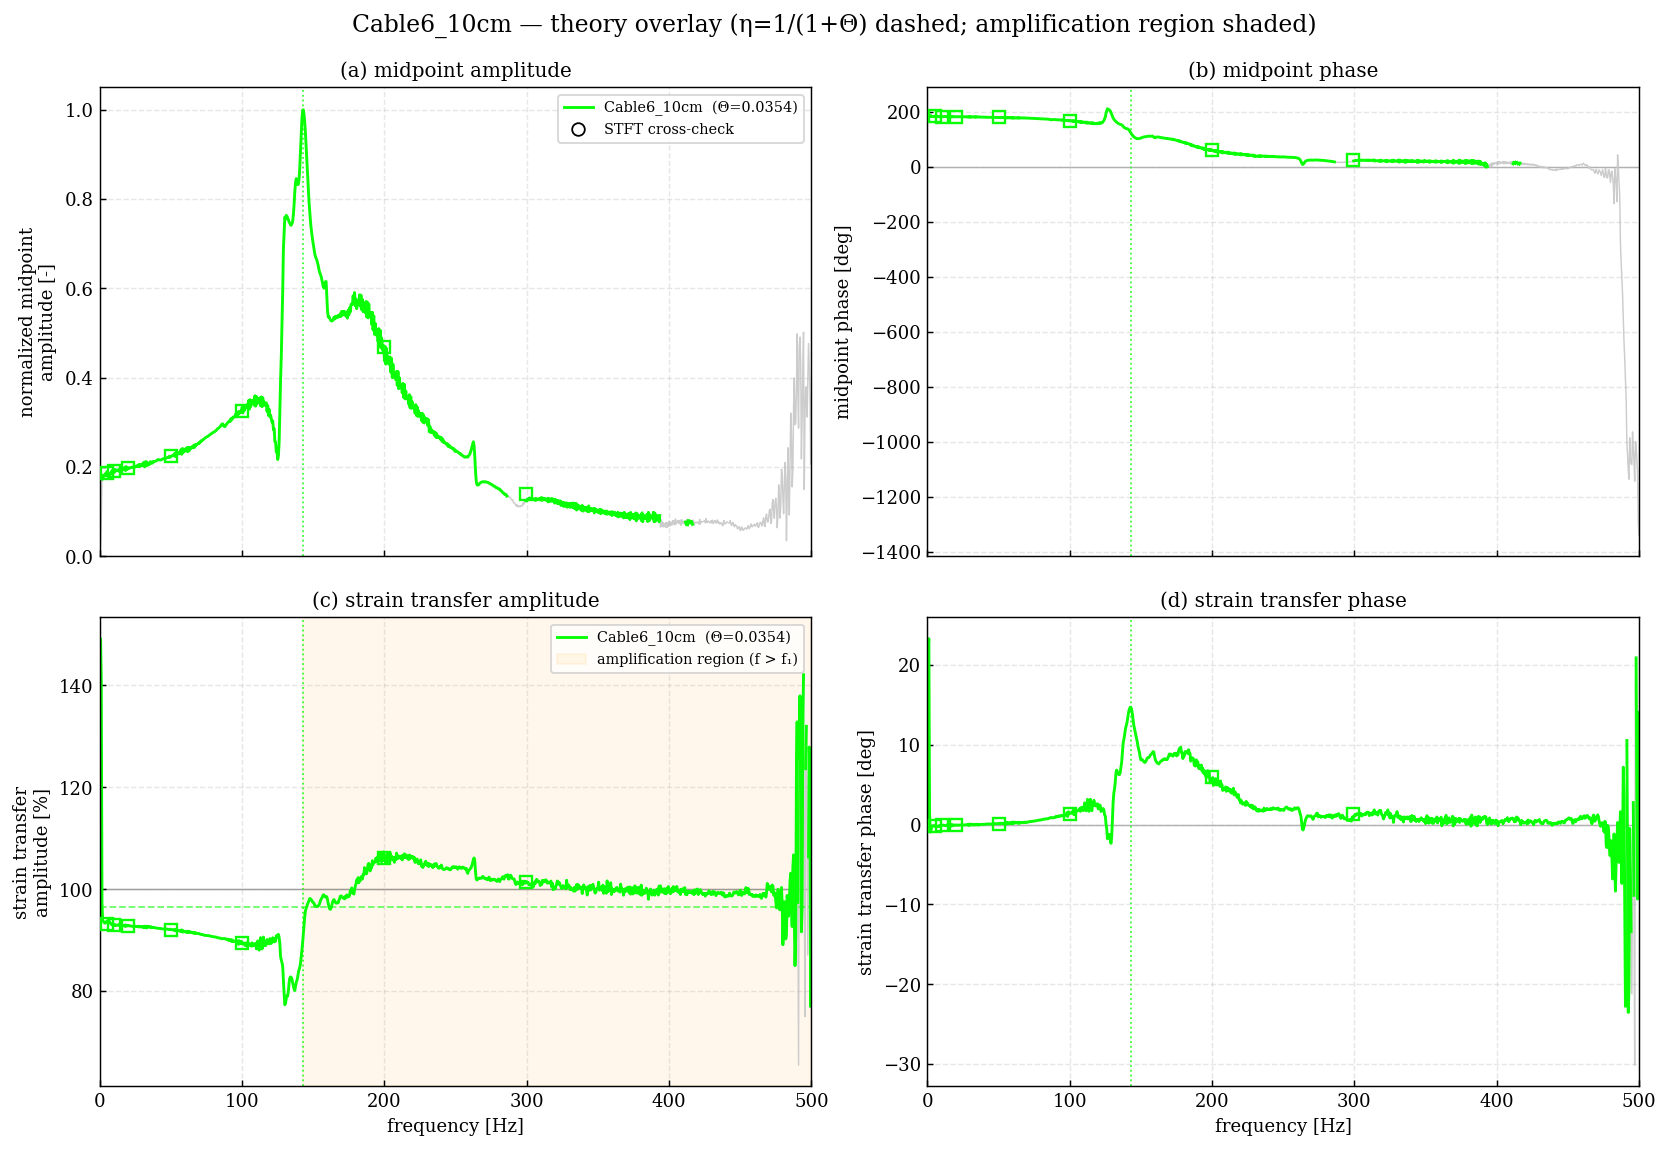

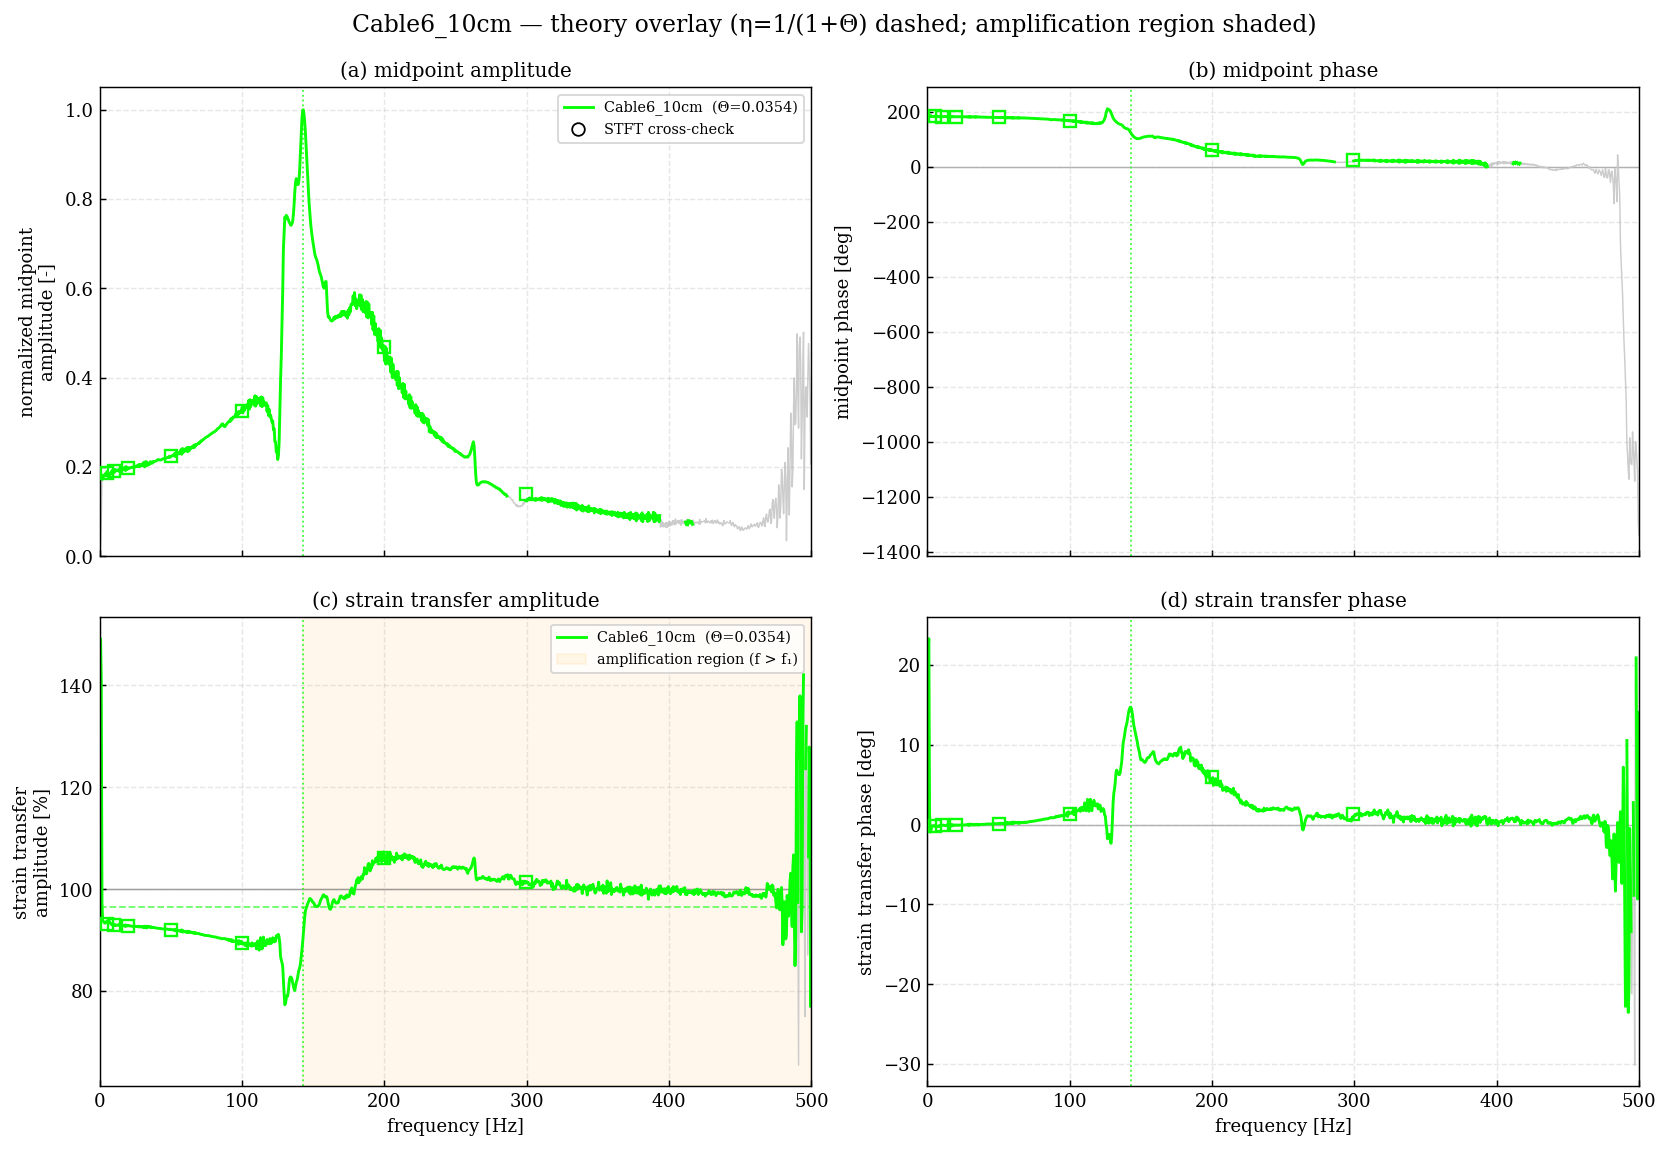

In [15]:
# Single-dataset view: panel (c) with eta_pred line and amplification region.
plotting.plot_fig3_transfer(DATASETS[:5],
                            f_max=max(F_MAX_PLOT, RES_FMAX * 0.7),
                            coh_thresh=0.7, show_stft=True, show_eta_pred=True,
                            title=f"{DATASETS[0]['label']} — theory overlay "
                                  "(η=1/(1+Θ) dashed; amplification region shaded)")

---
## § 7  Coupling Efficiency $\eta$ vs $\Theta$ (FRF method)

Average the FRF strain-transfer amplitude $\eta(f)=|H_\eta(f)|$ over a
quasi-static band for **every dataset**, then scatter against $\Theta$ exactly
like the time-domain plot (`plotting.plot_eta_vs_theta`), overlaid with the
theory $\eta=1/(1+\Theta)$.

$\eta$ here is $\langle|H_\eta(f)|\rangle$ over `[ETA_FMIN, ETA_FMAX]` using only
coherent bins ($\gamma^2\ge$ `ETA_COH`), with the $\delta L$ reference set by
`X_SOURCE` from § 1 (default `'ends'`). Marker colour = cable, shape = gap
(5/10/15 cm), open = intended-sag variant — same encoding as the existing
$\eta$–$\Theta$ figure.

> Loads and processes **all selected datasets** — heavy on first run (.mat files
> are ~10–17 MB each); cached afterwards. Trim `ETA_LABELS` to go faster.

In [16]:
# All sweep datasets (linearity tests excluded). Edit to subset.
ETA_LABELS = config.SWEEP_LABELS
ETA_DATASETS = config.select_datasets(ETA_LABELS)

ETA_FMIN, ETA_FMAX, ETA_COH = 5.0, 25.0, 0.7   # quasi-static band, coherence gate

for cfg in ETA_DATASETS:
    io.load_cable_dataset(cfg, verbose=False)
    analysis.prepare_geometry(cfg, sag_use_3d=True, sag_use_parabola=True)
    freqdomain.build_coupling_signals(cfg, x_source=X_SOURCE)
    freqdomain.compute_transfer_functions(cfg)
    em, es, n = freqdomain.band_mean_eta(cfg, ETA_FMIN, ETA_FMAX, ETA_COH)
    print(f"  {cfg['label']:18s} Θ={cfg['theta_pred']:.4g}  "
          f"η_pred={cfg['eta_pred']:.3f}  "
          f"η_meas={('%.3f' % em) if em is not None else ' n/a':>6}  (n_bins={n})")
print(f"\nProcessed {len(ETA_DATASETS)} datasets  "
      f"(δL = {X_SOURCE!r}, band {ETA_FMIN:.0f}–{ETA_FMAX:.0f} Hz, γ² ≥ {ETA_COH})")

  Cable1_5cm         Θ=0.008493  η_pred=0.992  η_meas= 0.990  (n_bins=41)
  Cable1_5cm_Sag     Θ=0.008939  η_pred=0.991  η_meas= 1.000  (n_bins=41)
  Cable1_10cm        Θ=0.02078  η_pred=0.980  η_meas= 1.007  (n_bins=41)
  Cable1_10cm_Sag    Θ=0.03614  η_pred=0.965  η_meas= 0.995  (n_bins=41)
  Cable1_15cm        Θ=0.03798  η_pred=0.963  η_meas= 0.911  (n_bins=41)
  Cable1_15cm_Sag    Θ=0.1364  η_pred=0.880  η_meas= 0.811  (n_bins=41)
  Cable2_5cm         Θ=0.004749  η_pred=0.995  η_meas= 0.995  (n_bins=41)
  Cable2_5cm_Sag     Θ=0.07104  η_pred=0.934  η_meas= 0.928  (n_bins=41)
  Cable2_10cm        Θ=0.006788  η_pred=0.993  η_meas= 0.889  (n_bins=18)
  Cable2_10cm_Sag    Θ=0.06012  η_pred=0.943  η_meas= 0.836  (n_bins=41)
  Cable2_15cm        Θ=0.01024  η_pred=0.990  η_meas= 0.981  (n_bins=41)
  Cable2_15cm_Sag    Θ=0.1853  η_pred=0.844  η_meas= 0.730  (n_bins=41)
  Cable3_5cm         Θ=0.006576  η_pred=0.993  η_meas= 0.965  (n_bins=41)
  Cable3_5cm_Sag     Θ=0.00631  η_pred=0.994  η_

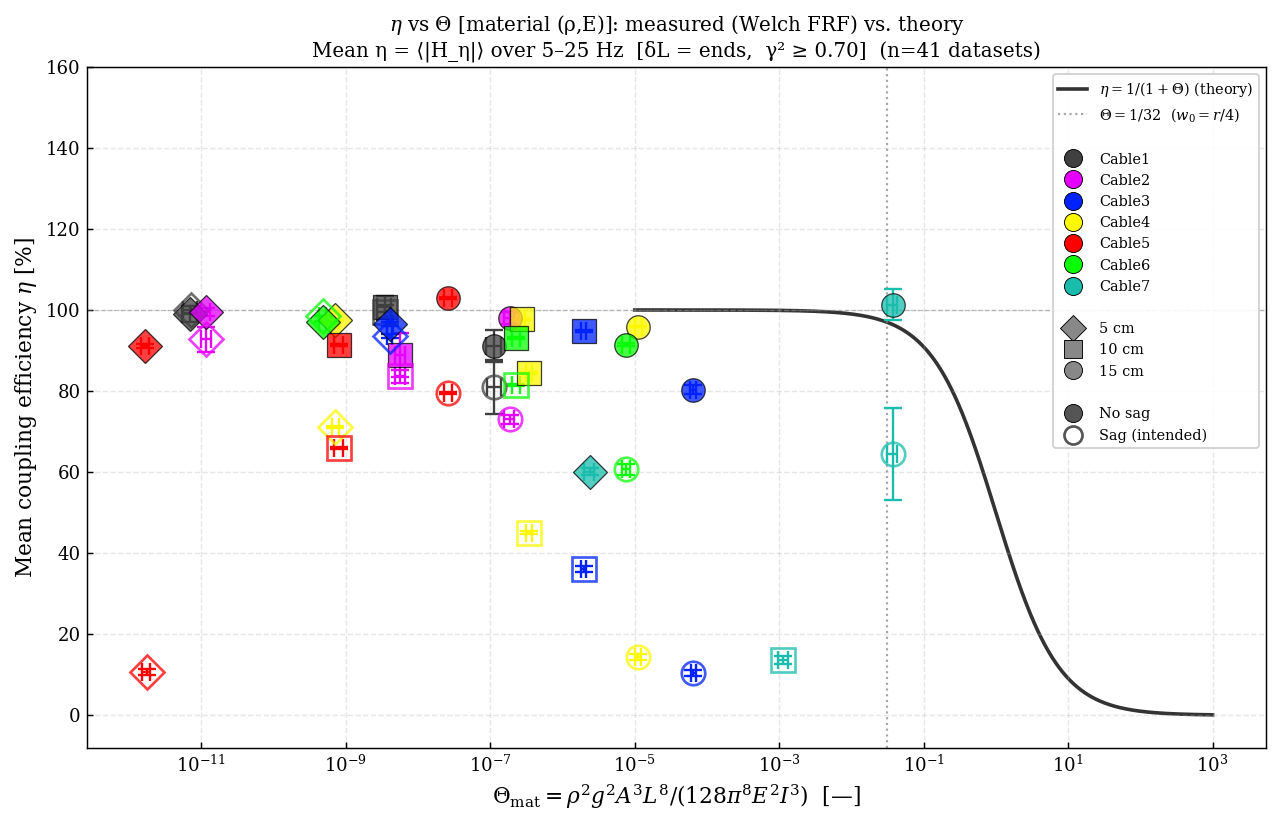

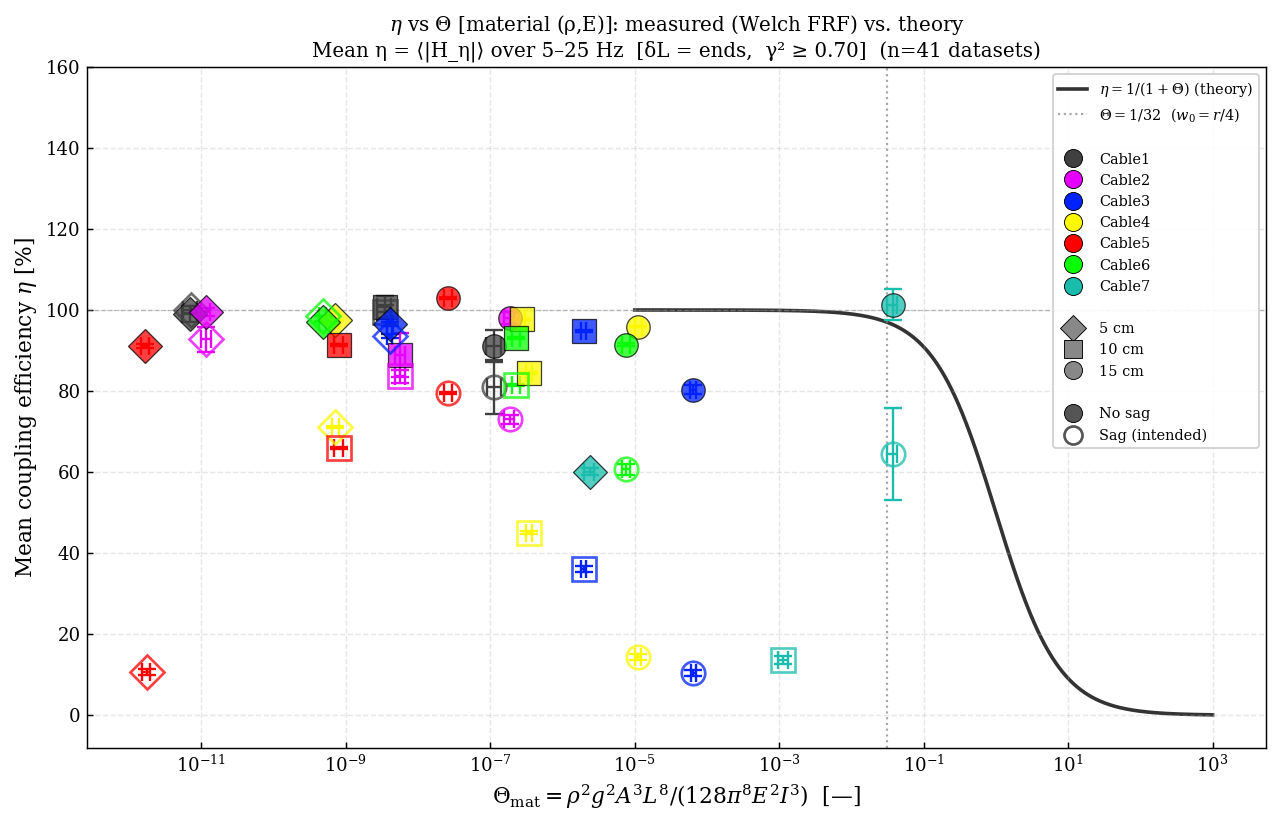

In [19]:
plotting.plot_eta_vs_theta_fd(
    ETA_DATASETS, f_min=ETA_FMIN, f_max=ETA_FMAX, coh_thresh=ETA_COH,
    theta_source='material', x_source=X_SOURCE, percent=True)
# theta_source='material' uses Θ from ρ,E instead of the measured sag.